In [ ]:
#Joyce Liu
#BSAN 360
#Project Assignments

#Part 1
#1
import pandas as pd
amazon = pd.read_csv("amazon_sales_dataset.csv")
amazon

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


In [ ]:
#2
amazon.shape
#There is 50000 rows and 13 columns in this dataset; Everything looks correct

(50000, 13)

In [ ]:
#3
amazon.head()
amazon.tail()
#Everything looks correct

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16
49999,50000,2023-06-29,2944,Home & Kitchen,253.44,30,1,Europe,Debit Card,2.1,464,177.41,177.41


In [ ]:
#4
amazon.columns
#Everything was inputted correctly

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

In [ ]:
#5a
df_q1 = amazon[["order_date", "price", "customer_region", "total_revenue"]]
df_q1
#Some example of what the column provide is the order date they purchase the product,
#the price is the cost of the product, and customer region is the region they're from, and total revenue
#is amount generated from that product within that period of time.
#5b
#The data type for Order_Date is datetime which tells us when each order was placed and analyze sales and
#customer behavior overtime
#The data type for Price is the numeric (real number) which is the price of the product
#The data type for Customer_Region is the character string, which helps us associate where the customer is
#from and helps us analyze/compare the sales across the regions.
#The data type for total_revenue is numeric. The revenue is amount generated from the order, typically
#calculated by the price*quantity
#5c
amazon["order_date"].min()
amazon["order_date"].max()
amazon["price"].min()
amazon["price"].max()
amazon["customer_region"].unique()
amazon["customer_region"].mode()
amazon["total_revenue"].min()
amazon["total_revenue"].max()
#5d
amazon["order_date"].isna().sum()
#There isn't any missing values in any of the columns


np.int64(0)

In [ ]:
#6
#In this dataset, I will analyze the Amazon Sales Dataset to identify trends and patterns of sales and
#customers over the period. This includes categories such as the items they bought, best performing products,
#price of product, and how sales vary from season to season. Some research questions I have is
#Q1.Do average sales differ significantly across different regions?
#Some columns I need to answer this question is the order date, price, customer region, total revenue
#Q2.Are there statistically significant differences in average sales across product categories?
#Some columns I need to answer this question is the order date, price, total revenue, product category
#Q3.Is sales growth consistent across regions over time?
#Some columns I need to answer this question is the order date, price, customer region, total revenue, and quantity
#sold


In [ ]:
#7
df_q1 = amazon[["order_date", "price", "customer_region", "total_revenue"]]
df_q1
df_q2 = amazon[["order_date", "price", "product_category", "total_revenue"]]
df_q2
df_q3 = amazon[["order_date", "price", "quantity_sold", "customer_region", "total_revenue"]]
df_q3

,order_date,price,quantity_sold,customer_region,total_revenue
0,2022-04-13,128.75,4,North America,463.52
1,2023-03-12,302.60,5,Asia,1210.40
2,2022-09-28,495.80,2,Europe,793.28
3,2022-04-17,371.95,4,Middle East,1264.64
4,2022-03-13,201.68,4,Middle East,806.72
...,...,...,...,...,...
49995,2022-09-03,26.99,5,Middle East,134.95
49996,2022-07-03,294.23,5,Asia,1324.05
49997,2023-02-17,352.11,4,Asia,985.92
49998,2022-09-30,307.54,1,Middle East,292.16


In [ ]:
#8
#For Questions 1 and 2, I believe ANOVA would be helpful to help and test whether region influences sales
#outcomes, and compares mean sales across multiple categories.
#For Question 3, I believe we can use a regression model using sales, time and region to test whether trends
#differ between regions.

In [ ]:
#Project Assignment 2
amazon = amazon[["order_date", "price", "quantity_sold", "product_category", "customer_region", "total_revenue"]]
amazon = amazon.rename(columns={"order_date": "Order_Date"})
amazon = amazon.rename(columns={"product_category": "Product_Category"})
amazon = amazon.rename(columns={"price": "Price"})
amazon = amazon.rename(columns={"quantity_sold": "Quantity_Sold"})
amazon = amazon.rename(columns={"customer_region": "Customer_Region"})
amazon = amazon.rename(columns={"total_revenue": "Total_Revenue"})
amazon["Order_Date"] = pd.to_datetime(amazon["Order_Date"], errors="coerce")
amazon_2023_first6 = amazon[(amazon["Order_Date"] >= "2023-01-01") & (amazon["Order_Date"] <= "2023-07-01")]
amazon_2023_first6 = amazon_2023_first6.sort_values(by="Order_Date",ascending=True)
amazon_2023_first6

,Order_Date,Price,Quantity_Sold,Product_Category,Customer_Region,Total_Revenue
8844,2023-01-01,67.98,5,Electronics,North America,288.90
27119,2023-01-01,107.93,1,Home & Kitchen,Europe,86.34
20147,2023-01-01,462.19,2,Electronics,North America,647.06
5959,2023-01-01,77.68,5,Beauty,North America,349.55
7289,2023-01-01,31.21,4,Sports,Europe,99.88
...,...,...,...,...,...,...
25265,2023-07-01,245.29,3,Electronics,North America,625.50
25386,2023-07-01,75.97,1,Fashion,North America,64.57
35648,2023-07-01,239.95,3,Books,Asia,683.85
37097,2023-07-01,17.50,2,Home & Kitchen,Europe,28.00


In [ ]:
#Project Assignment 3
#No merging or combining of datasets was required because all relevant
#variables were contained within a single file.
#All columns are capitalized
#No missing values
#First 6 months are filtered
#Date column converted to datetime
amazon.dtypes
amazon.isnull().sum()
pivot_region = amazon.pivot_table(
    index="Order_Date",
    columns="Customer_Region",
    values="Total_Revenue",
    aggfunc="sum"
)
pivot_region

pivot_category = amazon.pivot_table(
    index="Product_Category",
    columns="Customer_Region",
    values="Total_Revenue",
    aggfunc="sum"
)
pivot_category

melt = pivot_region.reset_index().melt(
    id_vars="Order_Date",
    var_name="Customer_Region",
    value_name="Total_Revenue"
)
melt

grouped = amazon.groupby(["Order_Date", "Customer_Region"])["Total_Revenue"].sum()
grouped
wide = grouped.unstack()
wide

Customer_Region,Asia,Europe,Middle East,North America
Order_Date,,,,
2022-01-01,12577.10,16190.37,7827.28,11265.62
2022-01-02,9729.73,9897.88,4334.81,11537.13
2022-01-03,9364.06,11433.25,10991.41,9141.15
2022-01-04,9406.61,9883.36,8760.42,6763.34
2022-01-05,11261.81,4751.22,15166.83,7136.86
...,...,...,...,...
2023-12-27,17612.57,10060.03,11930.14,8301.24
2023-12-28,17175.50,9780.17,8089.76,10194.20
2023-12-29,9689.87,9369.91,12546.96,12405.31


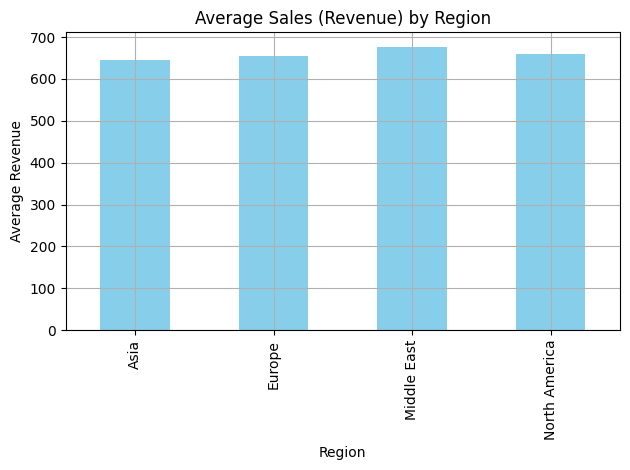

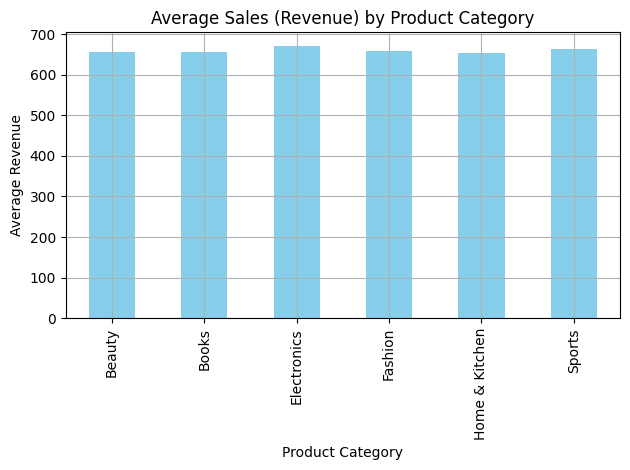

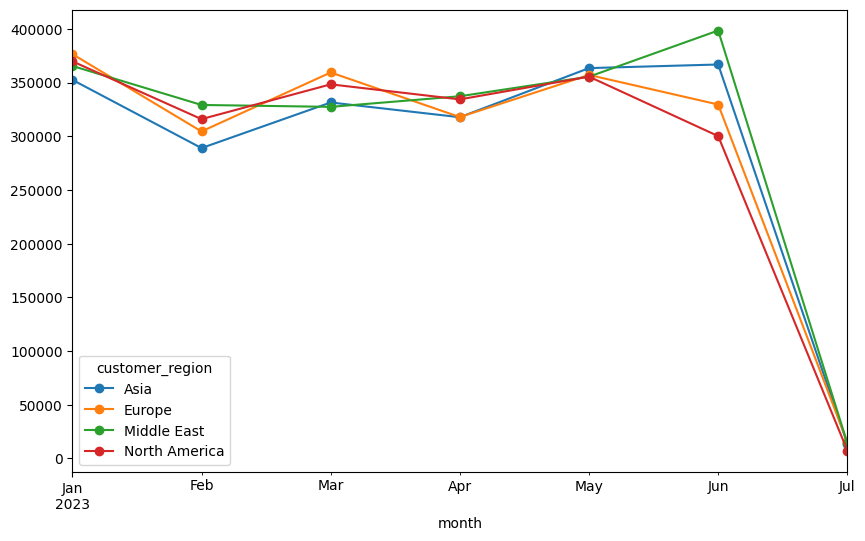

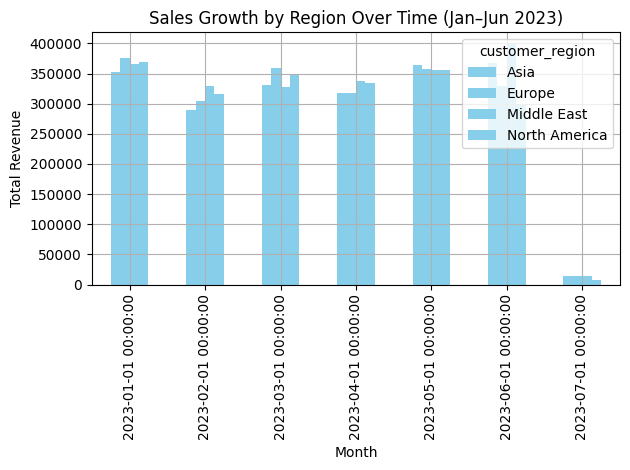

In [ ]:
#Project Assignment 4

import pandas as pd
import matplotlib.pyplot as plt
amazon = pd.read_csv("amazon_sales_dataset.csv")

#Q1
region_means = amazon_2023_first6.groupby("Customer_Region")["Total_Revenue"].mean()
region_means.plot(kind='bar', color='skyblue')
plt.title("Average Sales (Revenue) by Region")
plt.xlabel("Region")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.grid(True)
plt.show()

#Average sales do not differ significantly across the different regions. The mean is relatively the same, but Middle East has
#the highest sales within the 6 months of 2023.

#Q2
category_means = amazon_2023_first6.groupby("Product_Category")["Total_Revenue"].mean()
category_means.plot(kind='bar')
category_means.plot(kind='bar', color='skyblue')
plt.title("Average Sales (Revenue) by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.grid(True)
plt.show()

#There isn't much difference in average sales across product cateogories. Electronics seems to have the highest sale out of all
#category.

#Q3
amazon.columns = amazon.columns.str.strip().str.lower().str.replace(" ", "_")
amazon['order_date'] = pd.to_datetime(amazon['order_date'], errors='coerce')
amazon_2023_first6 = amazon[(amazon['order_date'] >= '2023-01-01') & (amazon['order_date'] <= '2023-07-01')].copy()
amazon['order_date'] = pd.to_datetime(amazon['order_date'])
amazon_2023_first6['month'] = amazon_2023_first6['order_date'].dt.to_period('M').dt.to_timestamp()

monthly_sales = amazon_2023_first6.groupby(['month', 'customer_region'])['total_revenue'].sum().unstack()
monthly_sales.plot(marker='o', figsize=(10,6))
monthly_sales.plot(kind='bar', color='skyblue')
plt.title("Sales Growth by Region Over Time (Jan–Jun 2023)")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.grid(True)
plt.show()

#Sales growth is pretty consistent throughout the region based off the graph. In June, Middle East spent the most out of the other regions. While
#North America spent the least.


Total Revenue: 8252052.57
Average Revenue: 8252052.57


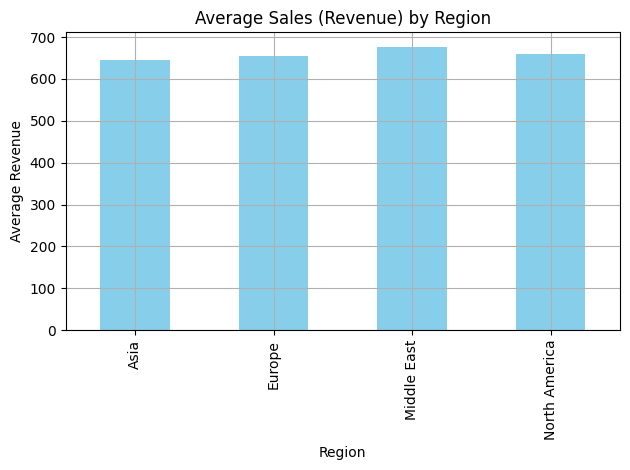

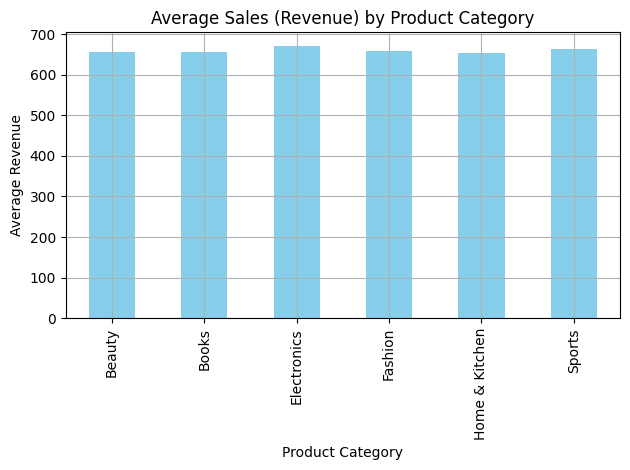

product_category  Beauty  Books  Electronics  Fashion  Home & Kitchen  Sports
customer_region                                                              
Asia                 552    535          517      502             529     522
Europe               523    517          538      525             542     495
Middle East          516    526          553      523             534     487
North America        557    501          485      517             484     531


In [ ]:
#Project Assignment 5
total_sales = amazon_2023_first6['total_revenue'].sum()
average_sales = amazon_2023_first6['total_revenue'].sum()
print("Total Revenue:", total_sales)
print("Average Revenue:", average_sales)

average_sales_means = amazon_2023_first6.groupby('customer_region')["total_revenue"].mean()
average_sales_means.plot(kind='bar', color='skyblue')
plt.title("Average Sales (Revenue) by Region")
plt.xlabel("Region")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.grid(True)
plt.show()

average_sales_category = amazon_2023_first6.groupby("product_category")["total_revenue"].mean()
average_sales_category.plot(kind='bar', color='skyblue')
plt.title("Average Sales (Revenue) by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.grid(True)
plt.show()
average_sales_category
average_sales_means

cross_tab = pd.crosstab(amazon_2023_first6['customer_region'],amazon_2023_first6['product_category'])
print(cross_tab)
#This shows how many orders occur in each region for each category

In [ ]:
#Project Assignment 6

#Q1
import pandas as pd
amazon['order_date'] = pd.to_datetime(amazon['order_date'])
amazon_2023_first6 = amazon[(amazon["order_date"] >= "2023-01-01") & (amazon["order_date"] <= "2023-07-01")].copy()
amazon_2023_first6['month'] = amazon_2023_first6['order_date'].dt.to_period('M')

import statsmodels.api as sm
import statsmodels.formula.api as smf
model_region = smf.ols('total_revenue ~ C(customer_region)',data=amazon_2023_first6).fit()
anova_region = sm.stats.anova_lm(model_region, typ=2)
print(anova_region)

#Q1.Do average sales differ significantly across different regions?
#Hypothesis: all regions have the same mean sales; Null: at least one region differs.
#Based off ANOVA , P>0.05 (0.0908>0.05) which means there is no significant difference between average
#sales across regions.

#Q2
model_category = smf.ols('total_revenue ~ C(product_category)',data=amazon_2023_first6).fit()
anova_category = sm.stats.anova_lm(model_category, typ=2)
print(anova_category)

#Q2.Are there statistically significant differences in average sales across product categories?
#The F is 0.322686, and pvalue is 0.89961. This tells us that the differences in cateogry averages are
#due to random variation. Overall, the sales are similar across product cateogries and does not explain
#differences in revenue.

#Q3
amazon_2023_first6['time'] = amazon_2023_first6['order_date'].rank(method='dense').astype(int)
regression_model = smf.ols('total_revenue ~ time * C(customer_region)',data=amazon_2023_first6).fit()
print(regression_model.summary())

#Q3.Is sales growth consistent across regions over time?
#pvalue for time is 0.445. 0.445>0.05, which tells us that sales don't have a significant trend over time.
#From January to June 2023, the revenues are consistent and does not significantly increase or decrease.
#All pvalues for the region (0.158,0.408,0.186) are greater than 0.05, which tells us that there is no statistical
#evidence that sales growth differ between regions. Regional sales trends behave similarly over time.

                          sum_sq       df         F    PR(>F)
C(customer_region)  1.794172e+06      3.0  2.157198  0.090846
Residual            3.467416e+09  12507.0       NaN       NaN
                           sum_sq       df         F   PR(>F)
C(product_category)  4.475491e+05      5.0  0.322686  0.89961
Residual             3.468763e+09  12505.0       NaN      NaN
                            OLS Regression Results                            
Dep. Variable:          total_revenue   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.422
Date:                Tue, 10 Mar 2026   Prob (F-statistic):              0.191
Time:                        16:55:57   Log-Likelihood:                -96146.
No. Observations:               12511   AIC:                         1.923e+05
Df Residuals:                   12503   BIC:                         1.924e